## Version 2.0

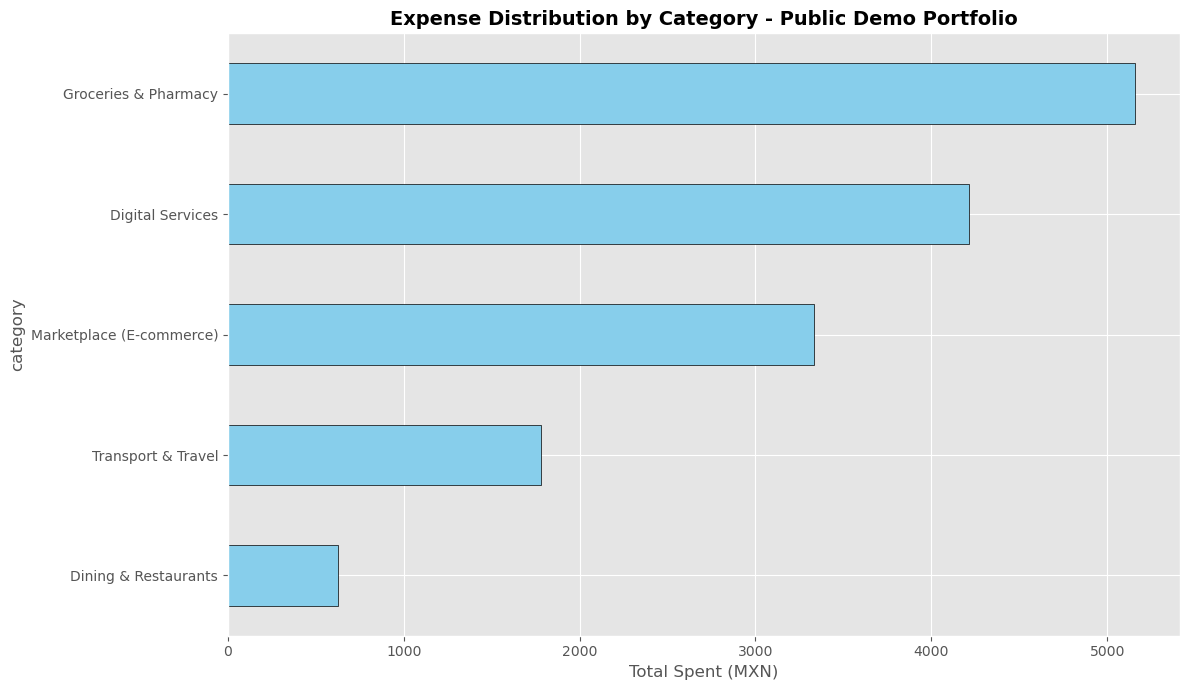


📈 DETAILED EXPENSE REPORT - PUBLIC SAMPLE

📁 Analyzing File: FakeEstadoDeCuenta | Total Monthly Spend: $15,109.00
--------------------------------------------------------------------------------
     date                  category                       description  \
18  21/02      Groceries & Pharmacy     Compra en SAMS NUEVO VALLARTA   
17  17/02  Marketplace (E-commerce)    Compra en MERPAGO*MERCADOLIBRE   
14  15/02          Digital Services    Compra en DISTROKID ULTIMATE 5   
3   07/02      Groceries & Pharmacy  Compra en SORIANA 853 B BANDERAS   
4   09/02          Digital Services            Compra en DLO*Starlink   
7   12/02          Digital Services      Compra en WL *Steam Purchase   
6   11/02        Transport & Travel           Compra en FLOGAS GASERA   
19  21/02        Transport & Travel        Compra en GAS VALLE DORADO   
11  14/02  Marketplace (E-commerce)    Compra en MERCADO PAGO 1 de 12   
8   13/02        Transport & Travel     Compra en EST FLAMINGOS NUEVA   



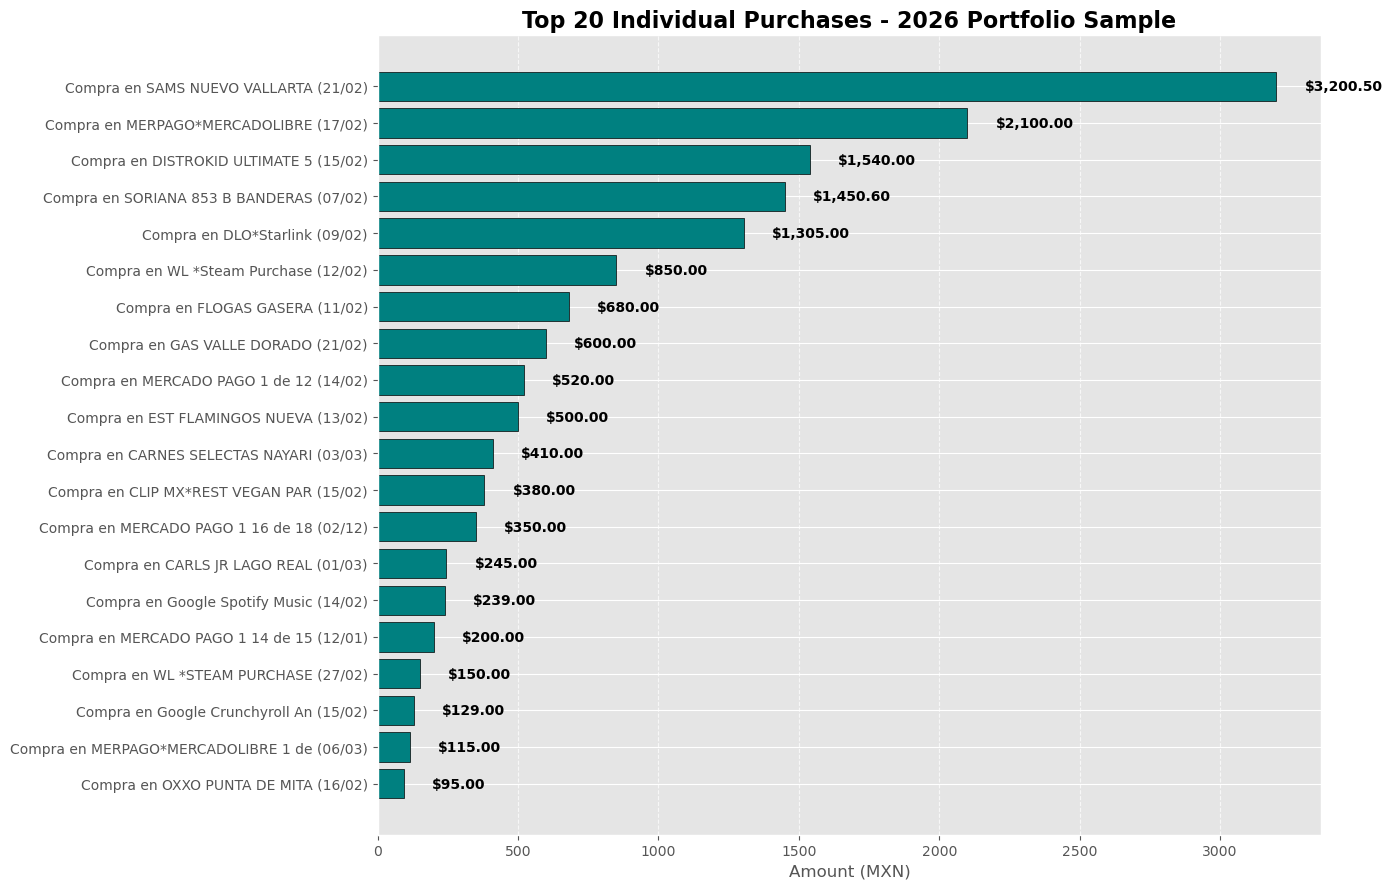

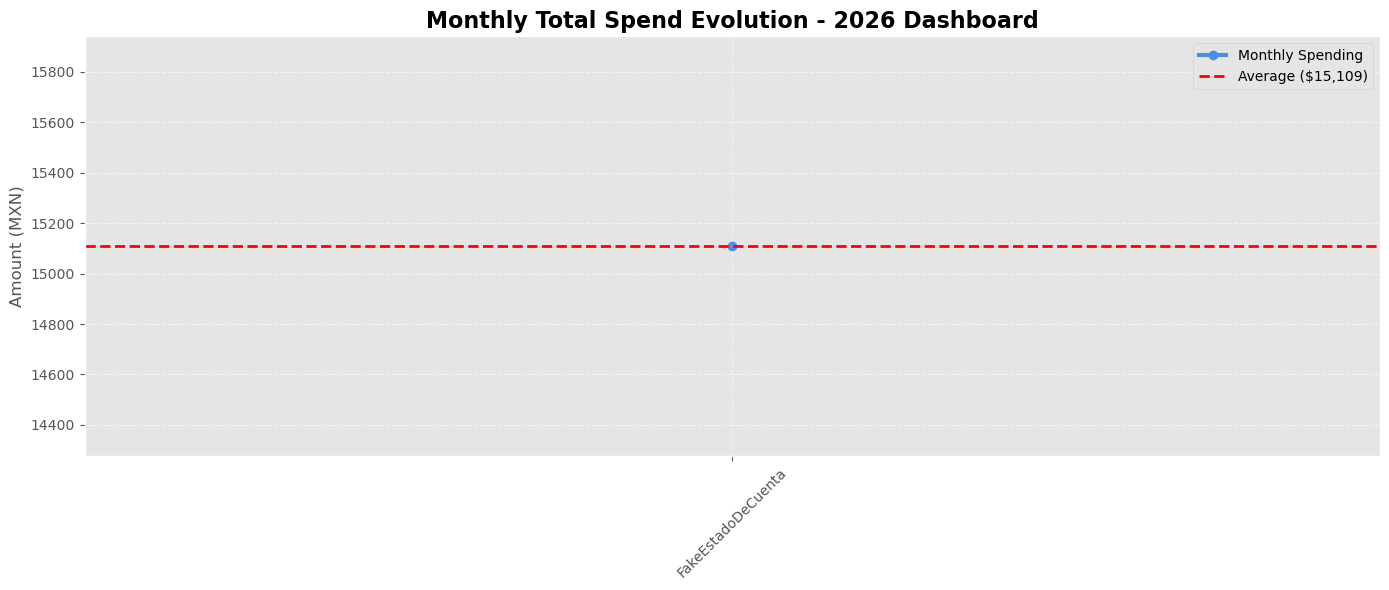

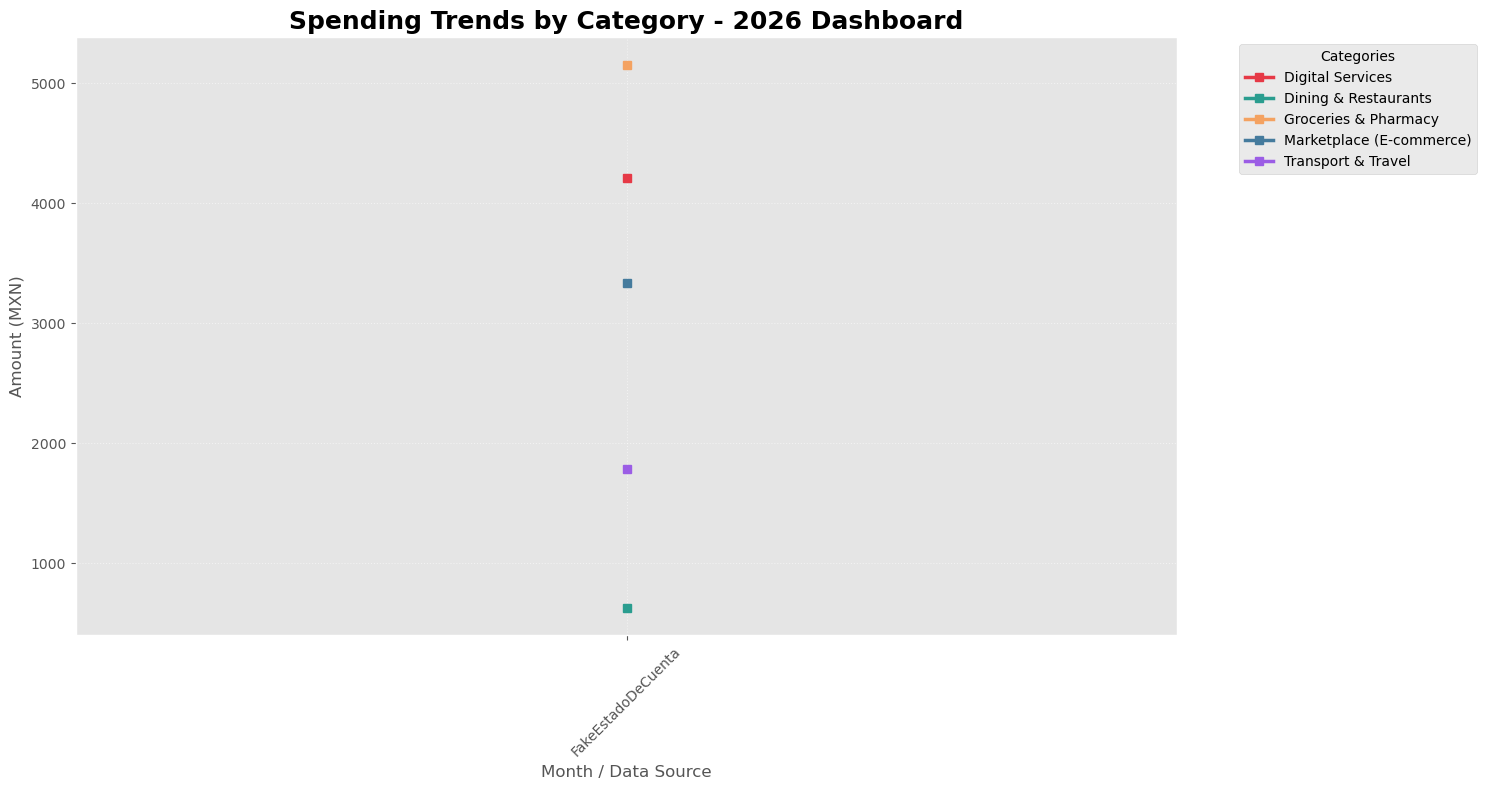

In [9]:
import os
import pdfplumber
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- HELPER FUNCTION FOR NATURAL SORTING (1, 2, 10...) ---
def natural_sort_key(s):
    """Sorts strings containing numbers in a human-friendly way."""
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

# =========================================================================
# --- 1. DATA ENGINE & CATEGORIZATION ---
# =========================================================================

def categorize_expenses(df):
    """Maps transaction descriptions to specific spending categories."""
    category_mapping = {
        'Marketplace (E-commerce)': r'MERCADO PAGO|MERPAGO|MELIMAS|MP ECOMMERCE|MERCADOLIBRE|MARKETPLACE',
        
        'Groceries & Pharmacy': r'COSTCO|FARM|CONSU MEDISIM|SN PABLO|LA COMER|SAMS|SORIANA|OXXO|KIOSKO|CONDIS|SUMESA|PETCO|FRUCAL|TCONE\*ABARROTES|ABARROTES|CARNES SELECTAS NAYARI|HOME DEP|FAR GUAD|NACIONAL 24H|CONVENIENCE STORE|GROCERY STORE',
        
        'Utilities & Housing': r'CFE CONTIGO|SEAPAL|TELCEL|TELMEX|IATI|AIRALO|EXP EN LIN ACTAS|GOB DE NAYARIT|INTERNET SERVICE',
        
        'Digital Services': r'STARLINK|SPOTIFY|AMAZON|GOOGLE|DAZN|OPUS|VIOLINSPIRATION|KASPERSKY|STEAM|CRUNCHYROLL|DISTROKID|OPENAI|CHATGPT|BETTERME|UDEMY|DOMESTIKA|DIGITAL_SERVICE_SUBS|STREAMING MUSIC PREMIUM|GAME STORE',
        
        'Transport & Travel': r'GAS |GASOL|UBER|FLOGAS|AUTOEXPRESS|ESTACION|OCTANO|KPETROM|VIVAAEROBUS|MANSIONH|HOTEL|TRIP.COM|EST FLAMINGOS NUEVA|GAS STATION|TRANSPORT APP',
        
        'Dining & Restaurants': r'TACOS|POLLO|STARBUCKS|CARLS JR|VEGAN|CULINARIA|TOSCANO|LATTE|KFC|BENITTOS|MEAT ON G|TAPIOCA|HELADOS|DOLPHY|TEPOZNIEVES|GABISTRO|REST NX|VEGAN RESTAURANT|COFFEE SHOP',
             
        'Maintenance & Electronics': r'POINTMP\*VML|ELECTRONICS STORE',
        
        'Financial & Fees': r'Intereses|Anualidad|Comisión|FINANZAS|Deferred payment|Interest fee|Monthly statement fee'
    }
    
    df['category'] = 'Other'
    for category, pattern in category_mapping.items():
        df.loc[df['description'].str.contains(pattern, case=False, na=False), 'category'] = category
        
    # Exclude non-expense entries (credit card usage, balance summaries, etc.)
    exclude_patterns = r'Uso de la tarjeta de cr[eé]dito|Saldo al corte|Resumen de movimientos|Cr[eé]dito|Credit'
    df = df[~df['description'].str.contains(exclude_patterns, case=False, na=False)]
    
    return df

def process_directory(folder_path):
    """Extracts data from PDFs and handles basic data cleaning."""
    transaction_list = []
    # Regex pattern to capture Date, Description, and Amount
    pattern = re.compile(r'(\d{2}/\d{2})\s+(.*?)\s+(-?\s?\$[\s]*[\d,]+\.\d{2})', re.DOTALL)
    
    if not os.path.exists(folder_path): 
        print(f"❌ Error: Path not found {folder_path}")
        return pd.DataFrame(), pd.DataFrame()

    files = [f for f in os.listdir(folder_path) if f.endswith(".pdf")]
    files.sort(key=natural_sort_key) 

    # Non-spending terms (Inflows/Internal transfers)
    non_expense_terms = [
        "Pago del resumen del", "Reembolso", "Uso de la tarjeta de credito", 
        "Uso de la tarjeta de crédito", "Saldo al corte", "Resumen de movimientos", 
        "Total de su pago", "Crédito", "Credit"
    ]

    for file in files:
        full_path = os.path.join(folder_path, file)
        with pdfplumber.open(full_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if not text: continue
                matches = pattern.findall(text)
                for date, desc, raw_amount in matches:
                    clean_desc = " ".join(desc.split())
                    numeric_amount = float(re.sub(r'[^\d.-]', '', raw_amount))
                    
                    norm_desc = clean_desc.lower().replace('é', 'e')
                    is_flow = any(t.lower().replace('é', 'e') in norm_desc for t in non_expense_terms)
                    
                    transaction_list.append({
                        'source_file': file.replace('.pdf', ''),
                        'date': date,
                        'description': clean_desc,
                        'amount_mxn': abs(numeric_amount),
                        'is_real_expense': not is_flow
                    })
    
    full_df = pd.DataFrame(transaction_list)
    if full_df.empty: return pd.DataFrame(), pd.DataFrame()

    expenses_df = full_df[full_df['is_real_expense'] == True].copy()
    inflows_df = full_df[full_df['is_real_expense'] == False].copy()
    
    expenses_df.drop(columns=['is_real_expense'], inplace=True)
    inflows_df.drop(columns=['is_real_expense'], inplace=True)
    
    return expenses_df, inflows_df

# =========================================================================
# --- 2. EXECUTION & ANALYSIS ---
# =========================================================================

github_path = r"C:\Users\Rod Cissan\CuentasRod\GitHubVer"
expenses_df, inflows_df = process_directory(github_path)

if not expenses_df.empty:
    expenses_df = categorize_expenses(expenses_df)
    
    # --- GLOBAL CATEGORY CHART ---
    yearly_summary = expenses_df.groupby('category')['amount_mxn'].sum().sort_values(ascending=False)
    plt.style.use('ggplot')
    plt.figure(figsize=(12, 7))
    yearly_summary.plot(kind='barh', color='skyblue', edgecolor='black')
    plt.gca().invert_yaxis()
    plt.title('Expense Distribution by Category - Public Demo Portfolio', fontweight='bold', fontsize=14)
    plt.xlabel('Total Spent (MXN)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- MONTHLY BREAKDOWN ---
    print("\n" + "="*80)
    print("📈 DETAILED EXPENSE REPORT - PUBLIC SAMPLE")
    print("="*80)

    file_list = sorted(expenses_df['source_file'].unique(), key=natural_sort_key)

    for file in file_list:
        monthly_df = expenses_df[expenses_df['source_file'] == file]
        monthly_total = monthly_df['amount_mxn'].sum()
        print(f"\n📁 Analyzing File: {file} | Total Monthly Spend: ${monthly_total:,.2f}")
        print("-" * 80)
        print(monthly_df.sort_values(by='amount_mxn', ascending=False)[['date', 'category', 'description', 'amount_mxn']].head(10))

# =========================================================================
# --- 3. AUDIT MODULE (VALIDATION) ---
# =========================================================================

def audit_categories(df, target_categories):
    """Extracts raw transaction details for validation purposes."""
    print("\n" + "🔍" * 30)
    print("🕵️ AUDIT REPORT: CATEGORIZATION VALIDATION")
    print("🔍" * 30)

    for cat in target_categories:
        audit_df = df[df['category'] == cat].copy()
        audit_df = audit_df.sort_values(by='amount_mxn', ascending=False)
        
        cat_total = audit_df['amount_mxn'].sum()
        count = len(audit_df)
        
        print(f"\n📂 CATEGORY: {cat.upper()}")
        print(f"📈 Audit Total: ${cat_total:,.2f} | 🧾 Transactions: {count}")
        print("-" * 80)
        
        if not audit_df.empty:
            print(audit_df[['date', 'source_file', 'description', 'amount_mxn']].to_string(index=False))
        else:
            print(f"⚠️ No transactions found for category '{cat}'.")
        print("-" * 80)

# Run Audit
categories_to_check = ['Groceries & Pharmacy', 'Digital Services']
if not expenses_df.empty:
    audit_categories(expenses_df, categories_to_check)

# =========================================================================
# --- 4. TOP 20 RANKING ---
# =========================================================================
print("\n" + "="*95)
print("🏆 ANNUAL RANKING: TOP 20 HIGHEST TRANSACTIONS")
print("="*95)

top_20_expenses = expenses_df.sort_values(by='amount_mxn', ascending=False).head(20)

print(f"{'#':<3} | {'Date':<8} | {'Category':<25} | {'Description':<40} | {'Amount MXN'}")
print("-" * 95)

for i, (_, row) in enumerate(top_20_expenses.iterrows(), 1):
    print(f"{i:<3} | {row['date']:<8} | {row['category']:<25} | {row['description'][:40]:<40} | ${row['amount_mxn']:>10,.2f}")

# Visualization: Top 20
plt.figure(figsize=(14, 9))
plt.barh(top_20_expenses['description'].str[:35] + " (" + top_20_expenses['date'] + ")", 
         top_20_expenses['amount_mxn'], 
         color='teal', edgecolor='black')

plt.gca().invert_yaxis()
plt.title('Top 20 Individual Purchases - 2026 Portfolio Sample', fontsize=16, fontweight='bold')
plt.xlabel('Amount (MXN)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_20_expenses['amount_mxn']):
    plt.text(v + 100, i, f'${v:,.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================================
# --- 5. TRENDS & TIME SERIES ANALYSIS ---
# =========================================================================

# Monthly Totals
monthly_summary = expenses_df.groupby('source_file')['amount_mxn'].sum().reset_index()
monthly_summary['sort_key'] = monthly_summary['source_file'].apply(natural_sort_key)
monthly_summary = monthly_summary.sort_values(by='sort_key').drop(columns=['sort_key'])

# Monthly Pivot by Category
pivot_summary = expenses_df.pivot_table(index='source_file', 
                                       columns='category', 
                                       values='amount_mxn', 
                                       aggfunc='sum').fillna(0)
pivot_summary['sort_key'] = pivot_summary.index.map(natural_sort_key)
pivot_summary = pivot_summary.sort_values(by='sort_key').drop(columns=['sort_key'])

# Average Spend Calculation
avg_monthly_spend = monthly_summary['amount_mxn'].mean()

# Visualization: Time Series Total
plt.figure(figsize=(14, 6))
plt.plot(monthly_summary['source_file'], monthly_summary['amount_mxn'], 
         marker='o', linestyle='-', color='#4A90E2', linewidth=3, label='Monthly Spending')
plt.axhline(y=avg_monthly_spend, color='red', linestyle='--', linewidth=2, 
            label=f'Average (${avg_monthly_spend:,.0f})')

plt.title('Monthly Total Spend Evolution - 2026 Dashboard', fontsize=16, fontweight='bold')
plt.ylabel('Amount (MXN)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Visualization: Category Trends
unique_colors = ['#E63946', '#2A9D8F', '#F4A261', '#457B9D', '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4', '#FEE440']

plt.figure(figsize=(15, 8))
for i, col in enumerate(pivot_summary.columns):
    plt.plot(pivot_summary.index, pivot_summary[col], 
             marker='s', label=col, linewidth=2.5,
             color=unique_colors[i % len(unique_colors)])

plt.title('Spending Trends by Category - 2026 Dashboard', fontsize=18, fontweight='bold')
plt.xlabel('Month / Data Source', fontsize=12)
plt.ylabel('Amount (MXN)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()